# Getting the relationships between InSAR coherence, water level and soil moisture (water content)
This code has been written for the ground data found at: https://catalogue.ceh.ac.uk/documents/3458e0b9-5002-4ddb-bcb3-1c7fb08fb70b
If using other data, it would be worth cleaning it to reflect this data.

## Imports

In [1]:
import os
import pandas as pd

from KnockfinMunsaryPipeline import get_data_dictionaries, get_coherence_line_graphs, GetOutcomes, \
    change_temperature_based_on_altitude, \
    get_coherence_precipitation_outputs_wick_data, GetMeansStandardDeviation, plot_weather_conditions
from src.GetDatesToRemoveBasedOnWeather import GetDatesToRemoveBasedOnWeather, WeatherAspect
from src.MovingWindowGraphs import WindowTimeframe
from src.GetDFGroundData import GetDFGroundData
from src.GetRollingPrecipitationDataframe import RollingPrecipitationDataframe

## Define variables

In [2]:
current_directory = os.getcwd()
parent_directory = os.path.abspath(os.path.join(current_directory, "../../.."))
path_to_base_data_directory = f'{parent_directory}/OneDrive_rzw_phd_OneDrive/PhD'

In [3]:
# Directories:
insar_unzipped = 'InSAR_unzipped_reference_date_spring'
insar_coherence = 'coherence_cropped'
reference_date = 'reference_date_20180402T175024'

# paths
root_directory = f'{path_to_base_data_directory}/Coding/{insar_unzipped}'
shape_files = f'{path_to_base_data_directory}/Coding/shape_files'
coherence_files = f'{path_to_base_data_directory}/Coding/{insar_coherence}/{reference_date}'
ground_data_path = f'{path_to_base_data_directory}/Data/water_table_Scotland/1be4eef2-0591-4073-bae2-e00b6ff4462f/data'

points_path = f'{path_to_base_data_directory}/Coding/shape_files_points'
reference_date_time_spring = '20180402T175024'
root_directory_spring = f'{path_to_base_data_directory}/Coding/{insar_unzipped}'

# variables:
temp_soil = 'Temp_Soil'
water_content = 'Water_Content'
temp_water = 'Temp_Water'
water_level = 'Water_level_meters'

locations_kh = ['Knockfin A', 'Knockfin B', 'Knockfin C', 'Knockfin D', 'Knockfin E', 'Knockfin F']
reference_date_time = '20180402T175024'
reference_date = '2018-04-02'
site_kh = 'KH'
subsites_kh = ['SITEA', 'SITEB', 'SITEC', 'SITED', 'SITEE', 'SITEF']

locations_mun = ['Munsary A', 'Munsary B', 'Munsary C', 'Munsary D', 'Munsary EF', 'Munsary G']
site_mun = 'MUN'
subsites_mun = ['SITEA', 'SITEB', 'SITEC', 'SITED', 'SITEEF', 'SITEG']

WEATHER_TEMPERATURE_COLUMN_HEADING = 'Temp_Soil'
WEATHER_TEMP_COLUMN_HEADING_WICK = 'tavg'

### Set weather aspect to remove
Choices are:
* NONE : no data removal
* PRECIPITATION_TIME : remove data when precipitation has occurred within 6 hours of Sentinel-1 data collection
* PRECIPITATION_AMOUNT : remove data when the precipitation amount is more than 20 mm
* TEMPERATURE : remove data when the temperature is less than 2 degrees C
* SNOW_ONLY : remove data when there is snow present
* Combinations: TEMPERATURE_AND_PRECIPITATION_AMOUNT, TEMPERATURE_AND_PRECIPITATION_TIME, PRECIPITATION_TIME_AMOUNT

In [4]:
weather_aspect = WeatherAspect.PRECIPITATION_TIME

### Set save directory
Best to name based on how the data is being reduced e.g. temperature_precipitation

In [5]:
path_to_save_directory = '/home/rachel/local_python/check_outcomes3'

if not os.path.exists(path_to_save_directory):
    os.makedirs(path_to_save_directory)

### Paths to local weather data

In [6]:
munsary_ef_weather = pd.read_csv(f'{ground_data_path}/MUN_ENV_SITEEF.csv')

knockfin_c_weather = pd.read_csv(f'{ground_data_path}/KH_ENV_SITEC.csv')


### Paths to regional weather data

In [7]:
file_path_wick_weather = f'{path_to_base_data_directory}/Data/water_table_Scotland/Wick_T_ppt_snow.csv'

wick_weather_dataframe = pd.read_csv(file_path_wick_weather)

wick_weather_dataframe['Date'] = pd.to_datetime(wick_weather_dataframe['Date'])

/tmp/ipykernel_397468/3927200162.py:5: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  wick_weather_dataframe['Date'] = pd.to_datetime(wick_weather_dataframe['Date'])


# Local Conditions included (Ground data)
### Get the dates to remove for each site. If no dates are to be removed:
* munsary_dates_to_remove = None
* knockfin_dates_to_remove = None

In [8]:
munsary_dates_to_remove = GetDatesToRemoveBasedOnWeather(munsary_ef_weather, weather_aspect,
                                                         WEATHER_TEMPERATURE_COLUMN_HEADING,
                                                         date_column_name='Date').get_dates_to_remove_from_coherence_data()

knockfin_dates_to_remove = GetDatesToRemoveBasedOnWeather(knockfin_c_weather, weather_aspect,
                                                          WEATHER_TEMPERATURE_COLUMN_HEADING,
                                                          date_column_name='Date').get_dates_to_remove_from_coherence_data()


## Get the focused data for each site

Maximum date is 2024-02-24 00:00:00


/home/rachel/local_python/insar_coherence_water_content_level_precipitation/src/GeoDataFrameLocationCoherence.py:153: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  geodataframe = geodataframe[~geodataframe['Date'].isin(self.data_to_remove)]


Maximum date is 2024-02-24 00:00:00
 The WT file does not exist for the KH SITEB site
 The WT file does not exist for the KH SITEB site


/home/rachel/local_python/insar_coherence_water_content_level_precipitation/src/GeoDataFrameLocationCoherence.py:153: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  geodataframe = geodataframe[~geodataframe['Date'].isin(self.data_to_remove)]


Maximum date is 2024-02-24 00:00:00


...

/home/rachel/local_python/insar_coherence_water_content_level_precipitation/src/GeoDataFrameLocationCoherence.py:153: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  geodataframe = geodataframe[~geodataframe['Date'].isin(self.data_to_remove)]


Maximum date is 2024-02-24 00:00:00


/home/rachel/local_python/insar_coherence_water_content_level_precipitation/src/GeoDataFrameLocationCoherence.py:153: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  geodataframe = geodataframe[~geodataframe['Date'].isin(self.data_to_remove)]


Maximum date is 2024-02-24 00:00:00


/home/rachel/local_python/insar_coherence_water_content_level_precipitation/src/GeoDataFrameLocationCoherence.py:153: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  geodataframe = geodataframe[~geodataframe['Date'].isin(self.data_to_remove)]


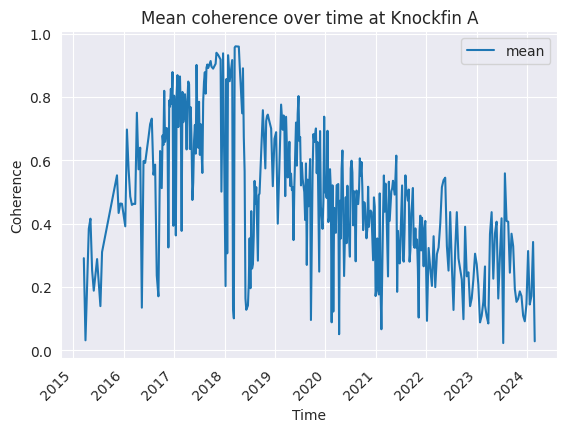

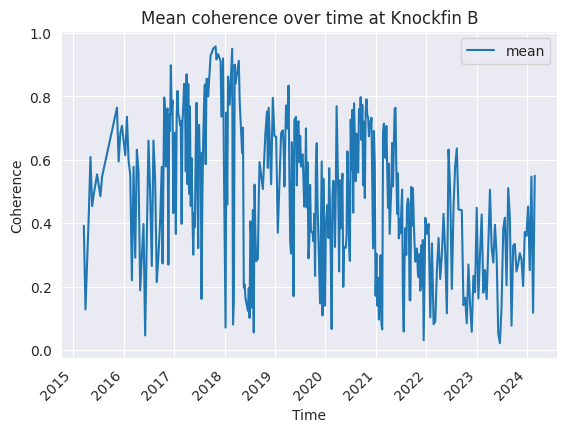

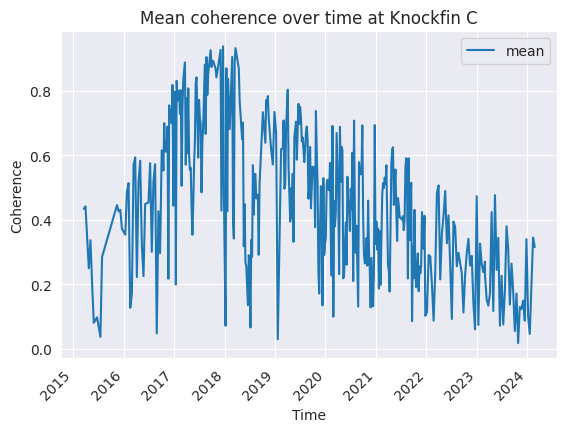

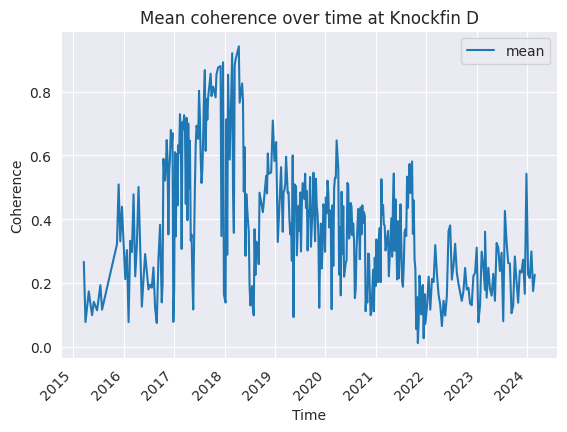

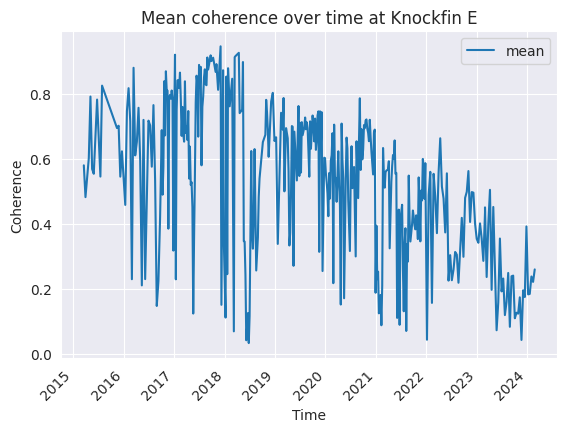

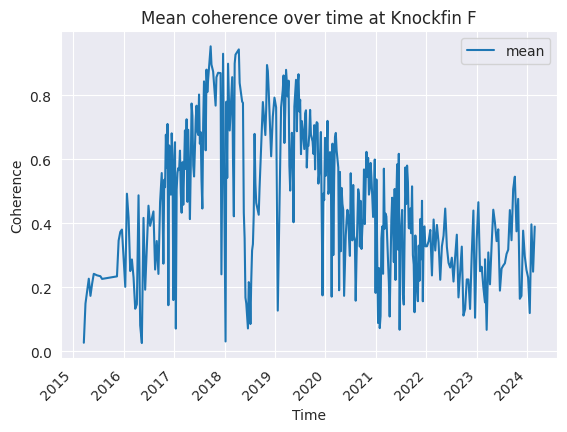

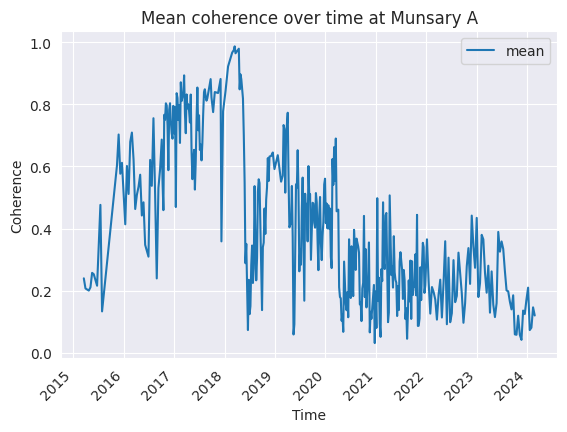

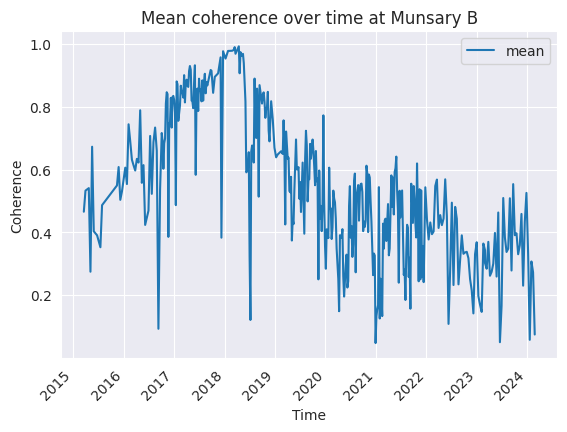

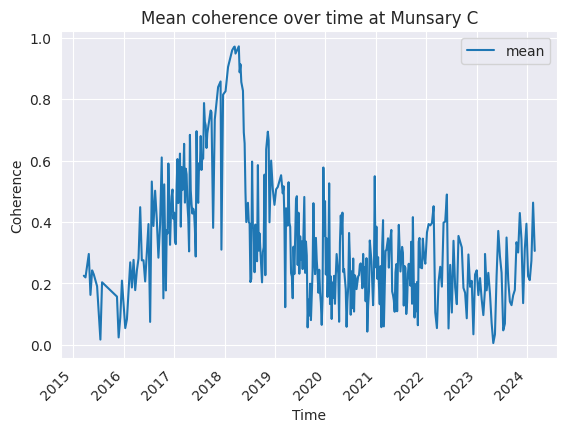

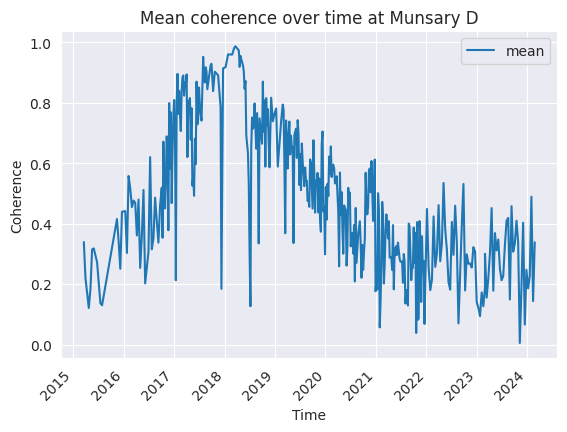

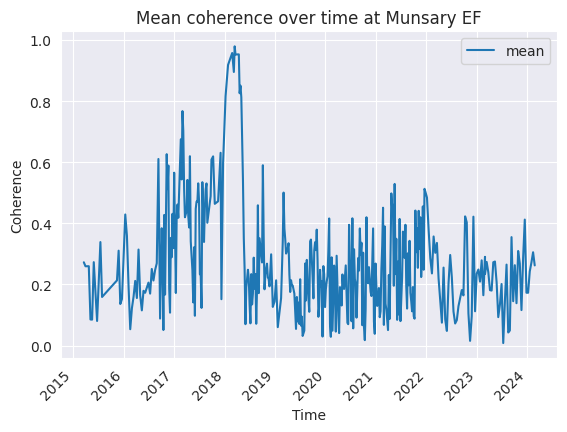

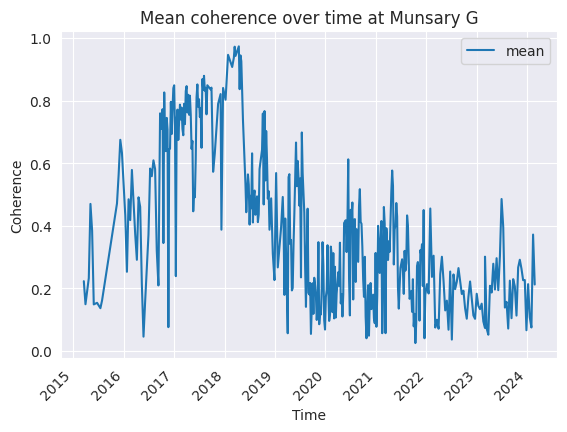

In [9]:
dictionary_of_data_dictionaries_knockfin = get_data_dictionaries(locations=locations_kh, site='KH',
                                                                 subsites=subsites_kh,
                                                                 dates_to_remove=knockfin_dates_to_remove,
                                                                 root_directory=root_directory,
                                                                 ground_data_path=ground_data_path,
                                                                 path_to_save_directory=path_to_save_directory, reference_date_time=reference_date_time, reference_date=reference_date, points_path=points_path)

dictionary_of_data_dictionaries_munsary = get_data_dictionaries(locations=locations_mun, site='MUN',
                                                                subsites=subsites_mun,
                                                                dates_to_remove=munsary_dates_to_remove,
                                                                root_directory=root_directory,
                                                                ground_data_path=ground_data_path,
                                                                path_to_save_directory=path_to_save_directory, reference_date_time=reference_date_time, reference_date=reference_date, points_path=points_path)

## Get line graphs for each site between InSAR coherence and water level + water content (soil moisture)

In [10]:
get_coherence_line_graphs(dictionary_of_data_dictionaries_knockfin, path_to_save_directory)

get_coherence_line_graphs(dictionary_of_data_dictionaries_munsary, path_to_save_directory)


## Get local precipitation data for each site

In [11]:
munsary_ef_ppt = GetDFGroundData(data_path=ground_data_path, data_type='ab', site='MUN', subsite='EF',
                                 variable='prcp').get_variable_and_date_specific_csv()

knockfin_c_ppt = GetDFGroundData(data_path=ground_data_path, data_type='ab', site='KH', subsite='SITEC',
                                 variable='prcp').get_variable_and_date_specific_csv()

munsary_ef_ppt = munsary_ef_ppt.rename(columns={'prcp': 'Precipitation_mm'})
knockfin_c_ppt = knockfin_c_ppt.rename(columns={'prcp': 'Precipitation_mm'})

In [12]:
GetOutcomes(path_to_save_directory, dictionary_of_data_dictionaries_knockfin, knockfin_c_ppt).get_outcomes()

GetOutcomes(path_to_save_directory, dictionary_of_data_dictionaries_munsary, munsary_ef_ppt).get_outcomes()

/home/rachel/local_python/insar_coherence_water_content_level_precipitation/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/rachel/local_python/insar_coherence_water_content_level_precipitation/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/rachel/local_python/insar_coherence_water_content_level_precipitation/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/home/rachel/local_python/insar_coherence_water_content_level_precipitation/src/MovingWindow.py:164: RankWarning: Polyfit may be poorly conditioned
  slope, intercept = np.polyfit(subset['Coherence'], subset[self.variable], 1)
/home/rachel/local_python/insar_coherence_water_content_level_preci

No water level data for Knockfin B


/home/rachel/local_python/insar_coherence_water_content_level_precipitation/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/rachel/local_python/insar_coherence_water_content_level_precipitation/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/rachel/local_python/insar_coherence_water_content_level_precipitation/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/home/rachel/local_python/insar_coherence_water_content_level_precipitation/src/MovingWindow.py:164: RankWarning: Polyfit may be poorly conditioned
  slope, intercept = np.polyfit(subset['Coherence'], subset[self.variable], 1)
/home/rachel/local_python/insar_coherence_water_content_level_preci

No water level data for Munsary C


/home/rachel/local_python/insar_coherence_water_content_level_precipitation/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/rachel/local_python/insar_coherence_water_content_level_precipitation/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/rachel/local_python/insar_coherence_water_content_level_precipitation/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/home/rachel/local_python/insar_coherence_water_content_level_precipitation/src/MovingWindow.py:164: RankWarning: Polyfit may be poorly conditioned
  slope, intercept = np.polyfit(subset['Coherence'], subset[self.variable], 1)
/home/rachel/local_python/insar_coherence_water_content_level_preci

# Regional Weather Data

In [13]:
one_month_rolling_precipitation = RollingPrecipitationDataframe(wick_weather_dataframe, WindowTimeframe.MONTH, 'prcp',
                                                                'Date', 1).get_rolling_mean_dataframe()

two_month_rolling_precipitation = RollingPrecipitationDataframe(wick_weather_dataframe, WindowTimeframe.MONTH, 'prcp',
                                                                'Date', 2).get_rolling_mean_dataframe()

six_week_rolling_precipitation = RollingPrecipitationDataframe(wick_weather_dataframe, WindowTimeframe.WEEK, 'prcp',
                                                               'Date', 6).get_rolling_mean_dataframe()

### Only run the next section if temperature is a factor

In [14]:
wick_weather_dataframe_T_sea_level = wick_weather_dataframe.copy()

wick_weather_dataframe_T_Munsary = change_temperature_based_on_altitude(wick_weather_dataframe, 2,
                                                                        wick_weather_dataframe)

wick_weather_dataframe_T_Knockfin = change_temperature_based_on_altitude(wick_weather_dataframe, 4.5,
                                                                         wick_weather_dataframe)

wick_weather_dataframe_T_Forsinard = change_temperature_based_on_altitude(wick_weather_dataframe, 6,
                                                                          wick_weather_dataframe)

## Continue

In [15]:
if weather_aspect == WeatherAspect.PRECIPITATION_AMOUNT or weather_aspect == WeatherAspect.PRECIPITATION_TIME:
    dates_to_remove_from_coherence_munsary = GetDatesToRemoveBasedOnWeather(wick_weather_dataframe,
                                                                            weather_aspect,
                                                                            WEATHER_TEMP_COLUMN_HEADING_WICK,
                                                                            date_column_name='Date').get_dates_to_remove_from_coherence_data()
    dates_to_remove_from_coherence_knockfin = dates_to_remove_from_coherence_munsary.copy()
    dates_to_remove_from_coherence_forsinard = dates_to_remove_from_coherence_munsary.copy()
else:
    dates_to_remove_from_coherence_munsary = GetDatesToRemoveBasedOnWeather(wick_weather_dataframe_T_Munsary,
                                                                            weather_aspect,
                                                                            'tavg_updated',
                                                                            date_column_name='Date').get_dates_to_remove_from_coherence_data()

    dates_to_remove_from_coherence_knockfin = GetDatesToRemoveBasedOnWeather(wick_weather_dataframe_T_Knockfin,
                                                                             weather_aspect,
                                                                             'tavg_updated',
                                                                             date_column_name='Date').get_dates_to_remove_from_coherence_data()

    dates_to_remove_from_coherence_forsinard = GetDatesToRemoveBasedOnWeather(wick_weather_dataframe_T_Forsinard,
                                                                              weather_aspect,
                                                                              'tavg_updated',
                                                                              date_column_name='Date').get_dates_to_remove_from_coherence_data()


/home/rachel/local_python/insar_coherence_water_content_level_precipitation/src/GetDatesToRemoveBasedOnWeather.py:114: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_dataframe = pd.concat([dataframe1, dataframe2], axis=0)


### Get InSAR coherence - regional precipitation outputs across focused and wider sites

In [16]:
points_path = f'{path_to_base_data_directory}/Coding/nearest_forsinard_psm'

knockfin_sites = ['Knockfin A', 'Knockfin B', 'Knockfin C', 'Knockfin D', 'Knockfin E', 'Knockfin F']
munsary_sites = ['Munsary A', 'Munsary B', 'Munsary C', 'Munsary D', 'Munsary EF', 'Munsary G']
sites_higher_altitude = ['buildings', 'farm', 'Forsinard lodge', 'pools4', 'pools5', 'plantation1', 'plantation2',
                         'plantation3', 'plantation4', 'drains1', 'drains2', 'drains3', 'drains4', 'gulley1', 'gulley2',
                         'gulley3', 'gulley4', 'peat1', 'peat2', 'peat3', 'peat4', 'buildings1', 'buildings3', 'pools1',
                         'pools2', 'pools3', 'plantation', 'gulley', 'drains',
                         'forsinard']

get_coherence_precipitation_outputs_wick_data(knockfin_sites, dates_to_remove_from_coherence_knockfin,
                                              root_directory_spring, points_path,
                                              path_to_save_directory, one_month_rolling_precipitation,
                                              six_week_rolling_precipitation, two_month_rolling_precipitation)


get_coherence_precipitation_outputs_wick_data(munsary_sites, dates_to_remove_from_coherence_munsary,
                                              root_directory_spring, points_path,
                                              path_to_save_directory, one_month_rolling_precipitation,
                                              six_week_rolling_precipitation, two_month_rolling_precipitation)


get_coherence_precipitation_outputs_wick_data(sites_higher_altitude, dates_to_remove_from_coherence_forsinard,
                                              root_directory_spring, points_path,
                                              path_to_save_directory, one_month_rolling_precipitation,
                                              six_week_rolling_precipitation, two_month_rolling_precipitation)

Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 00:00:00
Maximum date is 2024-02-24 0

# Combine all the text files generated into a csv

In [17]:
dfs = []

for filename in os.listdir(path_to_save_directory):
    if filename.endswith(".txt"):
        file_data_frame = pd.read_csv(os.path.join(path_to_save_directory, filename), sep=" ", header=None)
        substrings = filename.split("_")
        file_data_frame['site'] = "_".join(substrings[6:8])
        file_data_frame['window'] = "_".join(substrings[4:6])
        file_data_frame['variables'] = "_".join(substrings[2:4])
        dfs.append(file_data_frame)

df = pd.concat(dfs)

In [18]:
df = df.rename(columns={2: 'Pearson', 8: 'max_cross_cor', 14: 'min_cross_cor', })
df_focused = df[['Pearson', 'max_cross_cor', 'min_cross_cor', 'site', 'window', 'variables']]

In [19]:
name_addition = weather_aspect.value
df_focused.to_csv(f'{path_to_save_directory}/all_pearson_cross_correlation_{name_addition}.csv')

Creating Mean and Standard Deviation CSVs

In [20]:
name_addition = weather_aspect.value

imported_csv = pd.read_csv(f'{path_to_save_directory}/all_pearson_cross_correlation_{name_addition}.csv')

Cross correlation

In [21]:
knockfin_global_sites = ['Knockfin A_summary.txt', 'Knockfin B_summary.txt', 'Knockfin C_summary.txt',
                         'Knockfin D_summary.txt', 'Knockfin E_summary.txt', 'Knockfin F_summary.txt']
munsary_global_sites = ['Munsary A_summary.txt', 'Munsary B_summary.txt', 'Munsary C_summary.txt',
                        'Munsary D_summary.txt', 'Munsary EF_summary.txt', 'Munsary G_summary.txt']
sites_higher_altitude = ['buildings_summary.txt', 'farm_summary.txt', 'Forsinard lodge_summary.txt',
                         'pools4_summary.txt', 'pools5_summary.txt', 'plantation1_summary.txt',
                         'plantation2_summary.txt', 'plantation3_summary.txt', 'plantation4_summary.txt',
                         'drains1_summary.txt', 'drains2_summary.txt', 'drains3_summary.txt', 'drains4_summary.txt',
                         'gulley1_summary.txt', 'gulley2_summary.txt', 'gulley3_summary.txt', 'gulley4_summary.txt',
                         'peat1_summary.txt', 'peat2_summary.txt', 'peat3_summary.txt', 'peat4_summary.txt',
                         'buildings1_summary.txt', 'buildings3_summary.txt', 'pools1_summary.txt', 'pools2_summary.txt',
                         'pools3_summary.txt', 'plantation_summary.txt', 'gulley_summary.txt', 'drains_summary.txt',
                         'forsinard_summary.txt']
munsary_local_sites = ['munsary_a', 'munsary_b', 'munsary_c', 'munsary_d', 'munsary_ef', 'munsary_g']
knockfin_local_sites = ['knockfin_a', 'knockfin_b', 'knockfin_c', 'knockfin_d', 'knockfin_e', 'knockfin_f']

munsary_water_content_summary = GetMeansStandardDeviation(dataframe=imported_csv, sites=munsary_local_sites,
                                                          variable='coherence_water content',
                                                          variable_name='water_content',
                                                          test_name='max_cross_cor').get_means()
munsary_water_level_summary = GetMeansStandardDeviation(imported_csv, munsary_local_sites, 'coherence_water level',
                                                        'water_level', test_name='min_cross_cor').get_means()
knockfin_water_content_summary = GetMeansStandardDeviation(imported_csv, knockfin_local_sites,
                                                           'coherence_water content', 'water_content',
                                                           test_name='max_cross_cor').get_means()
knockfin_water_level_summary = GetMeansStandardDeviation(imported_csv, knockfin_local_sites, 'coherence_water level',
                                                         'water_level', test_name='min_cross_cor').get_means()

munsary_local_ppt_summary = GetMeansStandardDeviation(imported_csv, munsary_local_sites, 'coherence_precipitation',
                                                      'precipitation', test_name='max_cross_cor').get_means()
munsary_global_ppt_summary = GetMeansStandardDeviation(imported_csv, munsary_global_sites, 'coherence_precipitation',
                                                       'precipitation', test_name='max_cross_cor').get_means()
knockfin_local_ppt_summary = GetMeansStandardDeviation(imported_csv, knockfin_local_sites, 'coherence_precipitation',
                                                       'precipitation', test_name='max_cross_cor').get_means()
knockfin_global_ppt_summary = GetMeansStandardDeviation(imported_csv, knockfin_global_sites, 'coherence_precipitation',
                                                        'precipitation', test_name='max_cross_cor').get_means()

other_land_cover_ppt_summary = GetMeansStandardDeviation(imported_csv, sites_higher_altitude, 'coherence_precipitation',
                                                         'precipitation', test_name='max_cross_cor').get_means()

summary = pd.concat([munsary_water_content_summary, munsary_water_level_summary, knockfin_water_content_summary,
                     knockfin_water_level_summary, munsary_local_ppt_summary, munsary_global_ppt_summary,
                     knockfin_local_ppt_summary, knockfin_global_ppt_summary, other_land_cover_ppt_summary])
summary.to_csv(f'{path_to_save_directory}/munsary_knockfin_cross_correlation_summary_{name_addition}.csv')

Pearson

In [22]:
munsary_sites = ['munsary_a', 'munsary_b', 'munsary_c', 'munsary_d', 'munsary_ef', 'munsary_g']
knockfin_sites = ['knockfin_a', 'knockfin_b', 'knockfin_c', 'knockfin_d', 'knockfin_e', 'knockfin_f']

munsary_water_content_summary = GetMeansStandardDeviation(imported_csv, munsary_sites, 'coherence_water content',
                                                          'water_content').get_means()
munsary_water_level_summary = GetMeansStandardDeviation(imported_csv, munsary_sites, 'coherence_water level',
                                                        'water_level').get_means()
knockfin_water_content_summary = GetMeansStandardDeviation(imported_csv, knockfin_sites, 'coherence_water content',
                                                           'water_content').get_means()
knockfin_water_level_summary = GetMeansStandardDeviation(imported_csv, knockfin_sites, 'coherence_water level',
                                                         'water_level').get_means()

summary = pd.concat([munsary_water_content_summary, munsary_water_level_summary, knockfin_water_content_summary,
                     knockfin_water_level_summary])
summary.to_csv(f'{path_to_save_directory}/munsary_knockfin_summary_{name_addition}.csv')

## Plot local weather conditions over time for Knockfin Heights and Munsary

In [23]:
munsary_ef_temp_soil = GetDFGroundData(data_path=ground_data_path, data_type='ab', site='MUN', subsite='EF',
                                       variable='Temp_Soil').get_variable_and_date_specific_csv()

knockfin_c_temp_soil = GetDFGroundData(data_path=ground_data_path, data_type='ab', site='KH', subsite='SITEC',
                                       variable='Temp_Soil').get_variable_and_date_specific_csv()

weather_conditions_df_munsary = munsary_ef_ppt.merge(munsary_ef_temp_soil, on='Date')

weather_conditions_df_knockfin = knockfin_c_ppt.merge(knockfin_c_temp_soil, on='Date')

weather_conditions_df_munsary['Time'] = weather_conditions_df_munsary.index

weather_conditions_df_knockfin['Time'] = weather_conditions_df_knockfin.index


In [24]:
plot_weather_conditions(weather_conditions_df_munsary, 'munsary', path_to_save_directory)
plot_weather_conditions(weather_conditions_df_knockfin, 'knockfin', path_to_save_directory)